# Cosine Similarities Histogram on Positional Embeddings (Time and Embedding Dimensions)

## Imports

In [1]:
from transformers import GPT2Model, GPT2Tokenizer
import matplotlib.pyplot as plt
import numpy as np

In [2]:
gpt2 = GPT2Model.from_pretrained('gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Positional Embeddings

In [3]:
positionals = gpt2.wpe.weight.detach().numpy()
positionals.shape

(1024, 768)

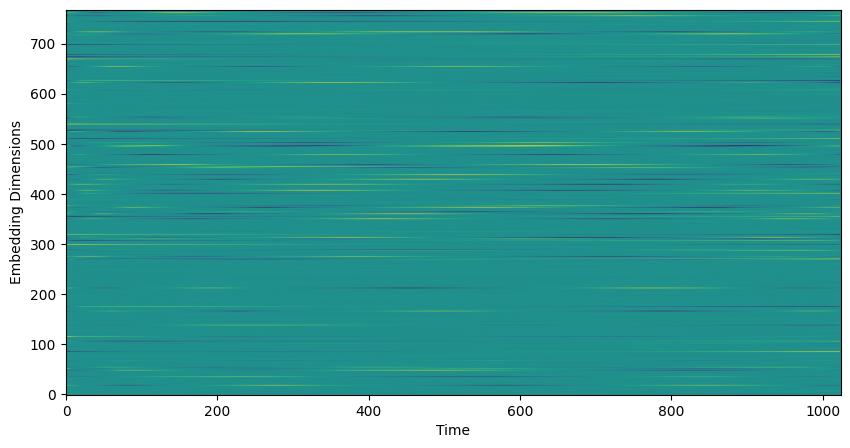

In [4]:
plt.figure(figsize = (10,5))
plt.imshow(positionals.T, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
plt.gca().set(xlabel = 'Time', ylabel = 'Embedding Dimensions')
plt.show()

## $S_c$ Cosine Similarities

$$ S_c = \frac{A\cdot B}{||A||\,||B||} = \frac{\sum_i^n{A_iB_i}}{\sum_i^nA_i^2\;\sum_i^nB_i^2} $$

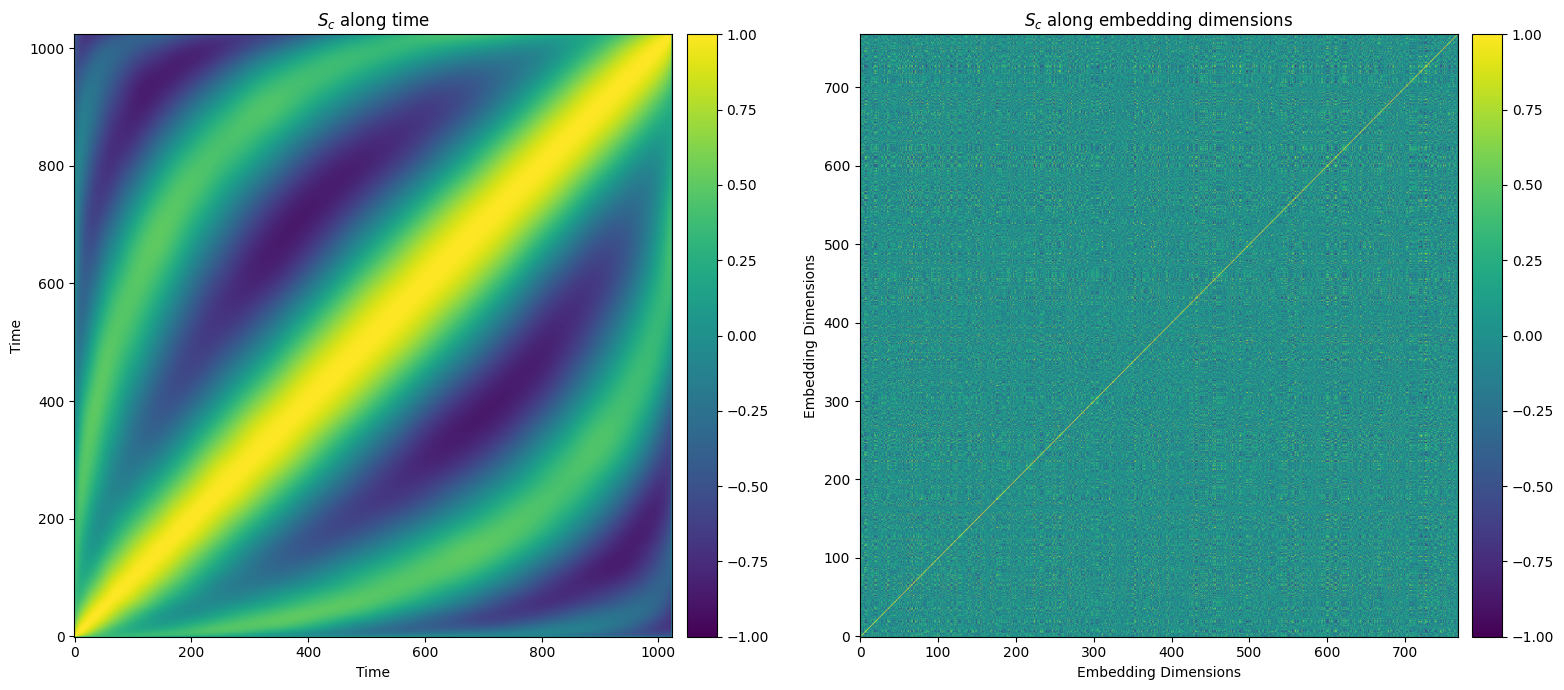

In [5]:
posnorm_0 = positionals / np.linalg.norm(positionals, axis = 1, keepdims = True)
cossim_0  = posnorm_0 @ posnorm_0.T

posnorm_1 = positionals / np.linalg.norm(positionals, axis = 0, keepdims = True)
cossim_1  = posnorm_1.T @ posnorm_1

fig, axs = plt.subplots(1,2,figsize=(16,7))

pl = axs[0].imshow(cossim_0, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
plt.colorbar(pl, ax = axs[0], pad = 0.02)
axs[0].set(title = '$S_c$ along time', xlabel = 'Time', ylabel = 'Time')

pl = axs[1].imshow(cossim_1, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
plt.colorbar(pl, ax = axs[1], pad = 0.02)
axs[1].set(title = '$S_c$ along embedding dimensions', xlabel = 'Embedding Dimensions', ylabel = 'Embedding Dimensions')

plt.tight_layout()
plt.show()

That

## Unique Cosine Similarities Histogram

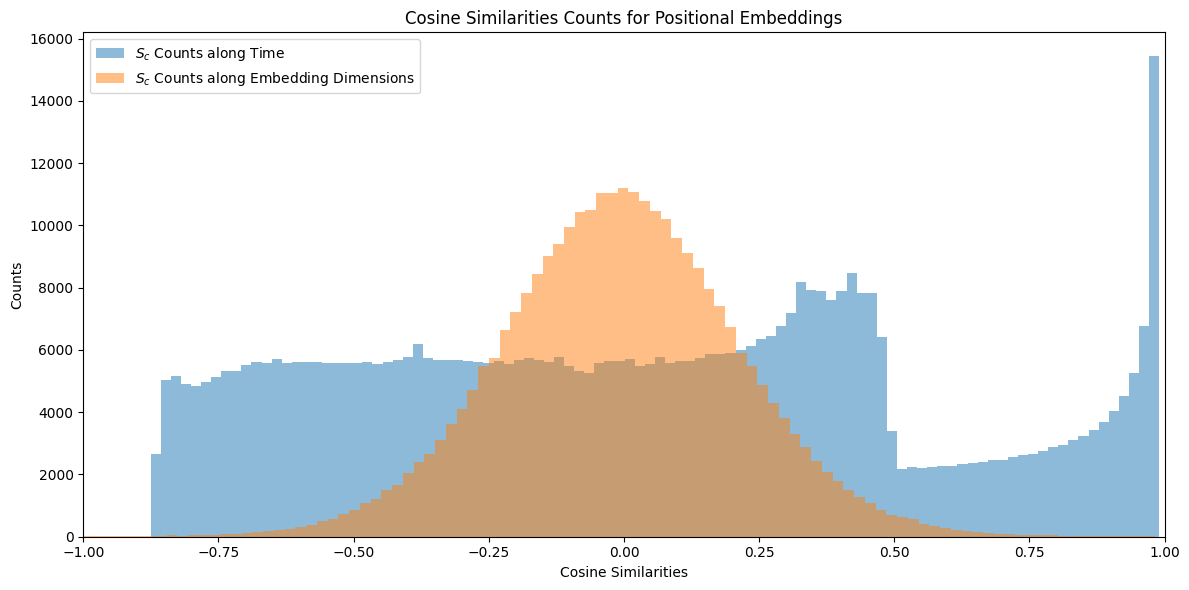

In [6]:
unique_cossim_0 = cossim_0[np.nonzero(np.triu(cossim_0,1))]
unique_cossim_1 = cossim_1[np.nonzero(np.triu(cossim_1,1))]

token_hy, token_hx = np.histogram(unique_cossim_0, 100)
embed_hy, embed_hx = np.histogram(unique_cossim_1, 100)

plt.figure(figsize = (12,6))

plt.bar(token_hx[:-1], token_hy, width = np.diff(token_hx[:2]), alpha = .5, label = '$S_c$ Counts along Time')
plt.bar(embed_hx[:-1], embed_hy, width = np.diff(embed_hx[:2]), alpha = .5, label = '$S_c$ Counts along Embedding Dimensions')

plt.legend()
plt.gca().set(title = 'Cosine Similarities Counts for Positional Embeddings', xlabel = 'Cosine Similarities', ylabel = 'Counts', xlim = [-1,1])
plt.tight_layout()
plt.show()

# Cosine Similarities on Positional Embeddings (Original Embedding Dimensions and Shuffled Embedding Dimensions)

## Imports

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import GPT2Model

In [8]:
gpt2 = GPT2Model.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Positional Embeddings

In [9]:
org_positionals = gpt2.wpe.weight.detach().numpy()
shuf_positionals = np.random.permutation(org_positionals.flatten()).reshape(org_positionals.shape)

org_positionals.shape, shuf_positionals.shape

((1024, 768), (1024, 768))

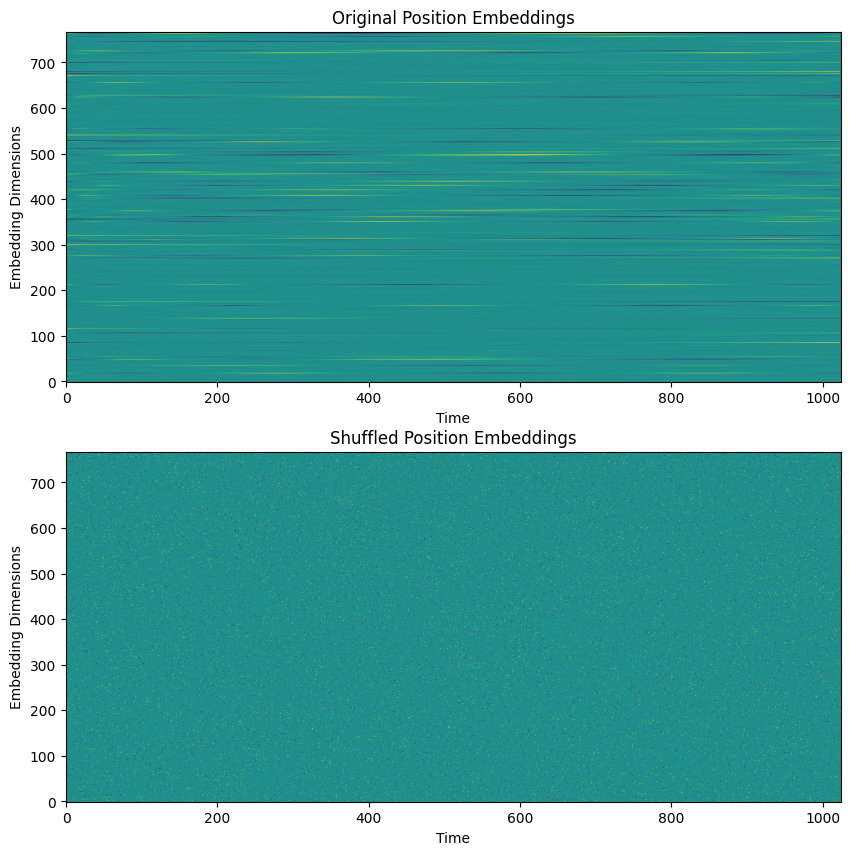

In [10]:
fig, axs = plt.subplots(2,1,figsize = (10,10))

axs[0].imshow(org_positionals.T, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
axs[0].set(title = 'Original Position Embeddings', xlabel = 'Time', ylabel = 'Embedding Dimensions')

axs[1].imshow(shuf_positionals.T, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
axs[1].set(title = 'Shuffled Position Embeddings', xlabel = 'Time', ylabel = 'Embedding Dimensions')
plt.show()

## $S_c$ Cosine Similarities

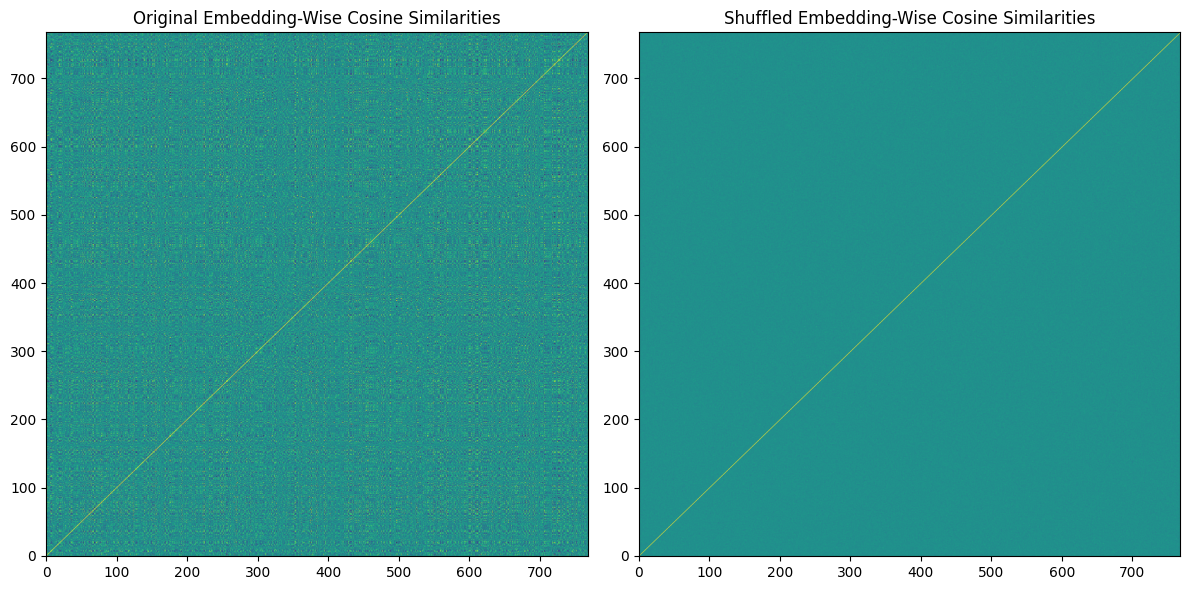

In [11]:
org_pos_norm_1 = org_positionals / np.linalg.norm(org_positionals, axis = 0, keepdims = True)
org_cossim_1 = org_pos_norm_1.T @ org_pos_norm_1

shuf_pos_norm_1 = shuf_positionals / np.linalg.norm(shuf_positionals, axis = 0, keepdims = True)
shuf_cossim_1 = shuf_pos_norm_1.T @ shuf_pos_norm_1

fig, axs = plt.subplots(1,2,figsize = (12,6))

axs[0].imshow(org_cossim_1, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
axs[0].set(title = 'Original Embedding-Wise Cosine Similarities')
axs[1].imshow(shuf_cossim_1, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
axs[1].set(title = 'Shuffled Embedding-Wise Cosine Similarities')

plt.tight_layout()
plt.show()

## Unique Cosine Similarities

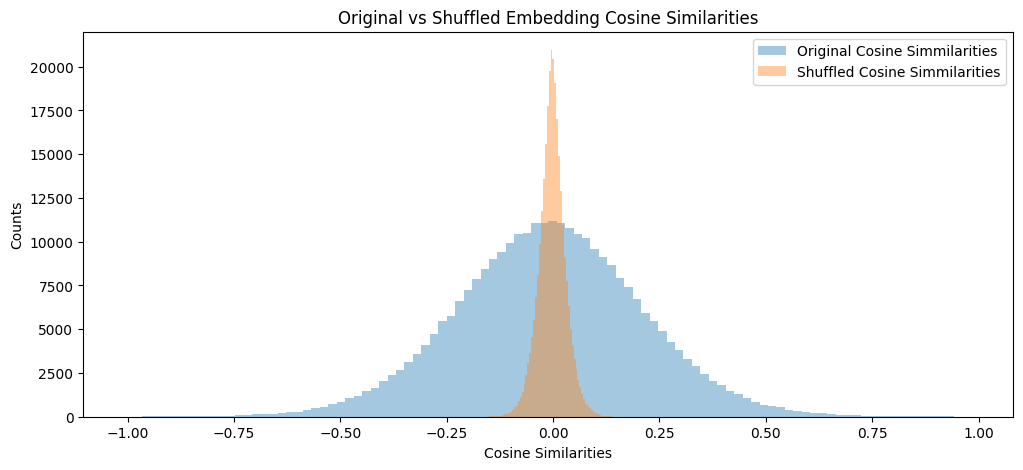

In [12]:
unq_org_cossim_1  = org_cossim_1[np.nonzero(np.triu(org_cossim_1, 1))]
shuf_org_cossim_1 = shuf_cossim_1[np.nonzero(np.triu(shuf_cossim_1, 1))]

org_hy, org_hx   = np.histogram(unq_org_cossim_1, 100)
shuf_hy, shuf_hx = np.histogram(shuf_org_cossim_1, 100)

plt.figure(figsize = (12,5))

plt.bar(org_hx[:-1], org_hy, width = np.diff(org_hx[:2]), alpha = .4, label = 'Original Cosine Simmilarities')
plt.bar(shuf_hx[:-1], shuf_hy, width = np.diff(shuf_hx[:2]), alpha = .4, label = 'Shuffled Cosine Simmilarities')

plt.legend()
plt.gca().set(title = 'Original vs Shuffled Embedding Cosine Similarities', xlabel = 'Cosine Similarities', ylabel = 'Counts')
plt.show()

# Similar Pairs

Cossim of 0.992 in pair (356, 528)
Cossim of 0.943 in pair (320, 540)
Cossim of 0.915 in pair (308, 528)
Cossim of 0.885 in pair (107, 271)
Cossim of 0.864 in pair (365, 525)
Cossim of 0.845 in pair (479, 623)
Cossim of 0.829 in pair (49, 724)
Cossim of 0.813 in pair (71, 365)
Cossim of 0.800 in pair (167, 439)
Cossim of 0.794 in pair (527, 623)


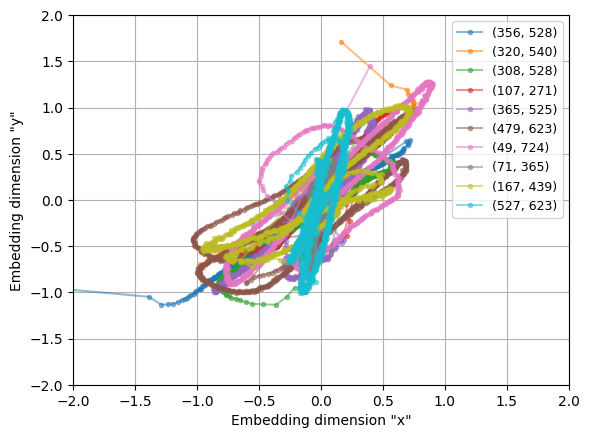

In [15]:
sortidx = np.argsort(np.triu(org_cossim_1,1).flatten())[::-1]
xx, yy = np.unravel_index(sortidx, org_cossim_1.shape)

for i in np.linspace(0,200,10).astype(int):

  # get and print the pairs
  pairname = f'({xx[i]}, {yy[i]})'
  print(f'Cossim of {org_cossim_1[xx[i], yy[i]]:.3f} in pair {pairname}')

  # plot them
  plt.plot(org_positionals[:,xx[i]], org_positionals[:,yy[i]], '.-', alpha = .5, label = pairname)

# adjustments
plt.gca().set(xlabel = 'Embedding dimension "x"', ylabel = 'Embedding dimension "y"')
plt.legend(fontsize = 9)
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.grid()
plt.show()